In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
image_path = "../output_videos/cropped_img.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

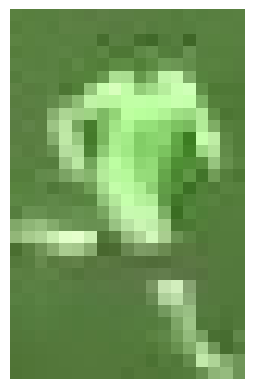

In [3]:
plt.imshow(image)
plt.axis("off")
plt.show()

### Take the top half of the image (means T-shirt)

In [4]:
image.shape

(30, 19, 3)

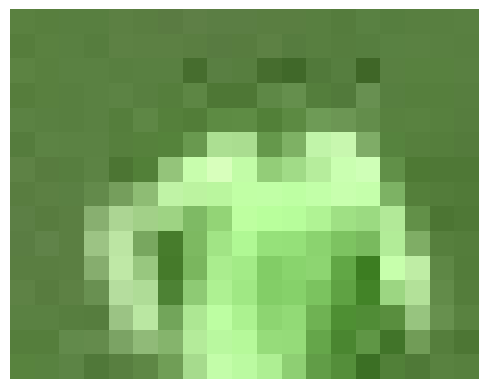

In [5]:
top_half_image = image[0:int(image.shape[0]/2),:]
plt.imshow(top_half_image)
plt.axis("off")
plt.show()

### Cluster image into 2 clusters
one is background another one is t-shirt color

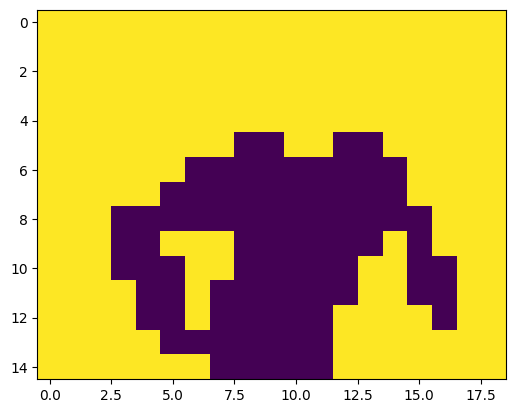

In [8]:
# Reshape the image into 2D
image_2d = top_half_image.reshape(-1,3)

# perform kmeans
kmeans = KMeans(n_clusters=2,random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels into orginal image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Display the clusted image
plt.imshow(clustered_image)
plt.show()

In [20]:
corner_clusters = [clustered_image[0,0],clustered_image[0,-1],clustered_image[-1,0],clustered_image[-1,-1]]
non_player_cluster = max(set(corner_clusters),key = corner_clusters.count)
print(non_player_cluster)

1


In [21]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [22]:
kmeans.cluster_centers_[player_cluster]

array([167.98823529, 226.31764706, 141.45882353])

([R=167.98823529, G=226.31764706, B=141.45882353]). these RGB color is same as T-shirt color. 